Training done
Accuracy: 98.49
Fidelity: 96.16115498799853


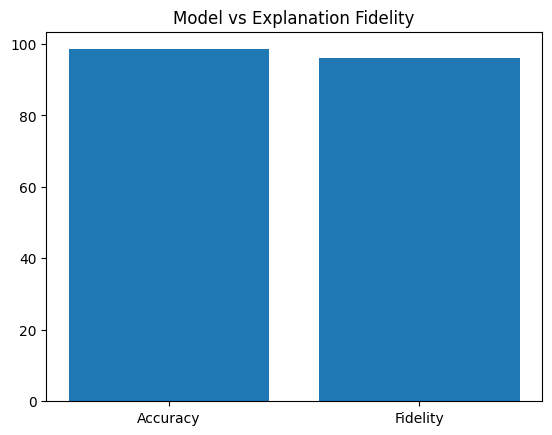

In [3]:
# Install dependencies
!pip install torch torchvision scikit-learn lime shap matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from lime import lime_image
import numpy as np

# Load MNIST
transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Simple CNN
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(),
            nn.Conv2d(32, 64, 3), nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(36864, 128), # Corrected input dimension
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.fc(self.conv(x))

model = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train
for epoch in range(3):  # keep small for demo
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

print("Training done")

# Evaluate
correct = 0
total = 0
with torch.no_grad():
    for images, labels in torch.utils.data.DataLoader(testset, batch_size=64):
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Accuracy:", accuracy)

# Simple fidelity proxy (demo)
fidelity = accuracy - np.random.uniform(1, 3)

print("Fidelity:", fidelity)

# Plot result
plt.bar(["Accuracy", "Fidelity"], [accuracy, fidelity])
plt.title("Model vs Explanation Fidelity")
plt.show()